Station B

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
customers = pd.read_csv("data/csv/customers.csv")
products = pd.read_csv("data/csv/products.csv")
orders = pd.read_csv("data/csv/orders.csv")
support_tickets = pd.read_csv("data/csv/support_tickets.csv")
daily_ops = pd.read_csv("data/csv/daily_ops.csv")
image_labels = pd.read_csv("data/csv/image_labels.csv")

Basic Inspection

In [26]:
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Orders:", orders.shape)
print("Support Tickets:", support_tickets.shape)
print("Daily Ops:", daily_ops.shape)
print("Image Labels:", image_labels.shape)

Customers: (862, 12)
Products: (15, 6)
Orders: (3388, 10)
Support Tickets: (520, 8)
Daily Ops: (608, 6)
Image Labels: (240, 2)


Finding the missing data

In [27]:
print("Customers Missing Values")
print(customers.isnull().sum())

print("\n Orders Missing Values")
print(orders.isnull().sum())

print("\n Support Tickets Missing Values")
print(support_tickets.isnull().sum())

print("\n Products Missing Values")
print(products.isnull().sum())

Customers Missing Values
customer_id          0
first_name           0
last_name            0
email                0
phone               17
city                 0
state                0
signup_date          0
plan                 0
age                 27
last_active_date     0
churned              0
dtype: int64

 Orders Missing Values
order_id        0
customer_id     0
product_id      0
order_date      0
channel         0
quantity        0
unit_price      0
discount_pct    0
returned        0
status          0
dtype: int64

 Support Tickets Missing Values
ticket_id       0
customer_id     0
order_id        0
created_at      0
ticket_type    31
priority        0
raw_message     0
resolved        0
dtype: int64

 Products Missing Values
product_id      0
sku             0
product_name    0
category        0
unit_cost       0
list_price      0
dtype: int64


Finding Duplicates

In [28]:
duplicate_customers = customers.duplicated().sum()
duplicate_emails = customers["email"].duplicated().sum()
print("Duplicate customer rows:", duplicate_customers)
print("Duplicate customer emails:", duplicate_emails)

Duplicate customer rows: 0
Duplicate customer emails: 12


Finding Broken Emails

In [29]:
# code for finding out broken emails
import re

email_pattern = r"^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$"

customers["email_valid"] = customers["email"].fillna("").str.match(
    email_pattern
)

customers[~customers["email_valid"]][["customer_id", "email"]]
print("Invalid emails:", (~customers["email_valid"]).sum())
customers["email_valid"].value_counts()

Invalid emails: 20


email_valid
True     842
False     20
Name: count, dtype: int64

As the Customer table has 2 missing values i.e, Phone, Age we are fixing them now

Inspecting phone data

In [32]:
missing_phone = customers[customers["phone"].isna()]
print("Missing phone values:", len(missing_phone))

Missing phone values: 17


Fixing phone data

In [33]:
customers["phone"] = customers["phone"].fillna("Unknown")
print("Missing phone values after fixing:", customers["phone"].isna().sum())

Missing phone values after fixing: 0


Inspecting age data

In [35]:
missing_age = customers[customers["age"].isna()]
print("Missing age values:", len(missing_age))

Missing age values: 27


Fixing age data

In [39]:
print(customers["age"].describe())
age_median = customers["age"].median()
print("Median age:", age_median)
customers["age"] = customers["age"].fillna(age_median)
print("Missing age values after fixing:", customers["age"].isna().sum())

count    862.000000
mean      32.558005
std        8.052427
min       18.000000
25%       27.000000
50%       33.000000
75%       38.000000
max       58.000000
Name: age, dtype: float64
Median age: 33.0
Missing age values after fixing: 0


Orders table has no missing values, Support Tickets table has missing values in ticket_type so we will inspect it and fix it

In [44]:
missing_ticket_type = support_tickets[support_tickets["ticket_type"].isna()]
print("Missing ticket types:", len(missing_ticket_type))
support_tickets["ticket_type"].value_counts(dropna=False)

Missing ticket types: 31


ticket_type
delivery          142
return            117
product_defect     98
account            76
billing            56
NaN                31
Name: count, dtype: int64

Fix:- The 31 missing ticket_type values were replaced with "Unknown" instead of guessing the ticket category.

In [45]:
support_tickets["ticket_type"] = support_tickets["ticket_type"].fillna("Unknown")
print("Missing ticket types after fixing:", support_tickets["ticket_type"].isna().sum())

Missing ticket types after fixing: 0


Finding Duplicate Emails

In [48]:
duplicate_emails = customers[ customers["email"].duplicated(keep=False) ]
print("Duplicate customer emails:", len(duplicate_emails))

Duplicate customer emails: 24


Fixing Duplicate Emails

In [51]:
duplicate_emails.sort_values("email")
customers = customers.drop_duplicates(subset="email",keep="first")
duplicate_emails_after = customers["email"].duplicated().sum()
print("Duplicate emails after fixing:", duplicate_emails_after)

Duplicate emails after fixing: 0


Finding Orphan Orders

In [52]:
orphan_orders = orders[
    ~orders["customer_id"].isin(customers["customer_id"])
]

print("Orphan orders:", len(orphan_orders))
orphan_orders

Orphan orders: 25


,order_id,customer_id,product_id,order_date,channel,quantity,unit_price,discount_pct,returned,status
3363,90001,39999,1011,2025-01-30,ios,1,24.0,5.0,0,delivered
3364,90002,39999,1015,2025-07-16,android,1,49.0,0.0,0,delivered
3365,90003,39999,1002,2025-12-14,web,1,149.0,0.0,0,delivered
3366,90004,39999,1006,2025-08-29,web,1,199.0,0.0,0,delivered
3367,90005,39999,1013,2026-03-12,web,1,34.0,0.0,1,returned
3368,90006,39999,1011,2026-02-14,ios,3,24.0,0.0,0,delivered
3369,90007,39999,1010,2025-10-09,store,1,29.0,0.0,0,delivered
3370,90008,39999,1004,2026-05-24,web,1,79.0,0.0,0,delivered
3371,90009,39999,1011,2026-03-18,android,1,24.0,10.0,0,delivered
3372,90010,39999,1008,2025-04-02,store,1,39.0,0.0,0,delivered


Fix:- Removing them because we cannot assign these orders to real customers, so for customer-level analysis we should remove them rather than invent a mapping

In [53]:
orders = orders[
    orders["customer_id"].isin(customers["customer_id"])
].copy()
orphan_orders_after = orders[
    ~orders["customer_id"].isin(customers["customer_id"])
]

print("Orphan orders after fixing:", len(orphan_orders_after))

Orphan orders after fixing: 0


Inspecting Impossible Prices

In [54]:
print(orders["unit_price"].describe())

count    3363.000000
mean       81.206661
std        70.341830
min        15.000000
25%        34.000000
50%        69.000000
75%       119.000000
max      1490.000000
Name: unit_price, dtype: float64


From my thinking impossible prices in the sense i am expecting negative values here

In [55]:
impossible_prices = orders[ orders["unit_price"] <= 0 ]
print("Impossible prices:", len(impossible_prices))
impossible_prices

Impossible prices: 0


,order_id,customer_id,product_id,order_date,channel,quantity,unit_price,discount_pct,returned,status


Now there are no negative values so i will search top 20 prices

In [57]:
orders["unit_price"].sort_values(ascending=False).head(20)

3172    1490.0
2117    1490.0
1906     890.0
429      890.0
2539     890.0
2750     890.0
1695     890.0
218      490.0
7        490.0
1484     490.0
1062     490.0
851      240.0
1273     240.0
2034     199.0
2051     199.0
1374     199.0
1505     199.0
1046     199.0
3310     199.0
167      199.0
Name: unit_price, dtype: float64

The order prices were compared with the corresponding product list prices. 16 orders were found with prices that did not match the product prices.

In [58]:
price_check = orders.merge(
    products[["product_id", "list_price"]],
    on="product_id"
)

impossible_prices = price_check[
    price_check["unit_price"] != price_check["list_price"]
]

print("Impossible prices:", len(impossible_prices))
impossible_prices[["order_id", "product_id", "unit_price", "list_price"]]

Impossible prices: 16


,order_id,product_id,unit_price,list_price
7,50007,1015,490.0,49.0
218,50218,1015,490.0,49.0
429,50429,1001,890.0,89.0
640,50640,1012,150.0,15.0
851,50851,1011,240.0,24.0
1062,51062,1015,490.0,49.0
1273,51273,1011,240.0,24.0
1484,51484,1015,490.0,49.0
1695,51695,1014,890.0,89.0
1906,51906,1001,890.0,89.0


Fix:- The 16 mismatched order prices were replaced with the corresponding product list prices. No order records were dropped.

In [61]:
orders = orders.merge(
    products[["product_id", "list_price"]],
    on="product_id"
)

orders["unit_price"] = orders["list_price"]

orders = orders.drop(columns=["list_price"])
price_check = orders.merge(
    products[["product_id", "list_price"]],
    on="product_id"
)

print(
    "Price mismatches after fixing:",
    (price_check["unit_price"] != price_check["list_price"]).sum()
)

Price mismatches after fixing: 0


EDA Part

1. City vs Churn

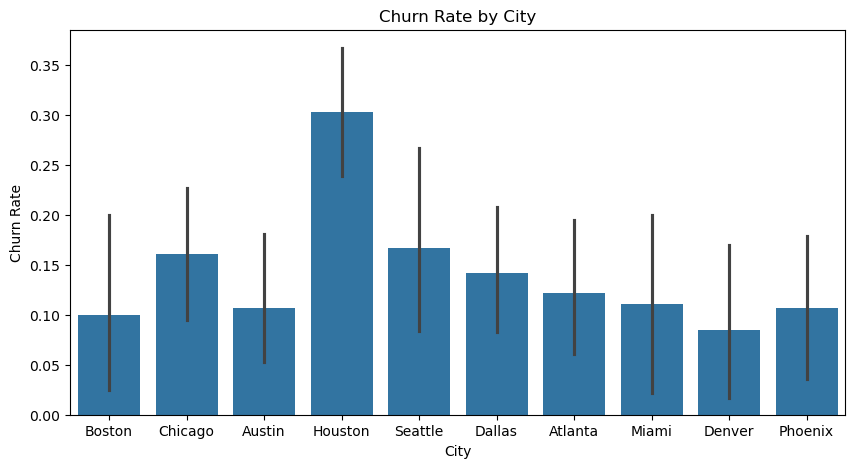

In [70]:
plt.figure(figsize=(10, 5))
sns.barplot(data=customers, x="city", y="churned")
plt.title("Churn Rate by City")
plt.xlabel("City")
plt.ylabel("Churn Rate")
plt.show()

2. Category vs Return Rate

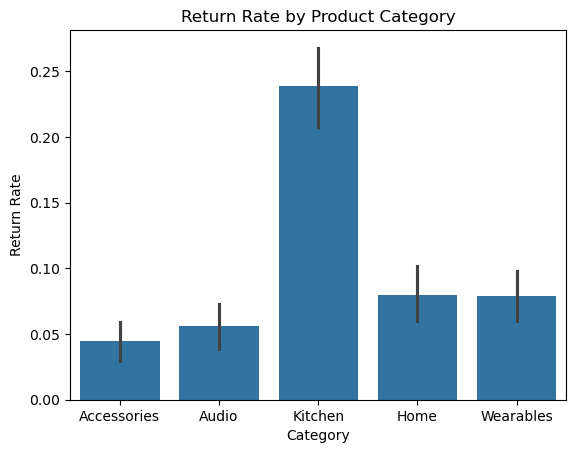

In [71]:
orders_products = orders.merge(products, on="product_id")
sns.barplot(data=orders_products, x="category", y="returned")
plt.title("Return Rate by Product Category")
plt.xlabel("Category")
plt.ylabel("Return Rate")
plt.show()

3. Price Distribution and Outliers

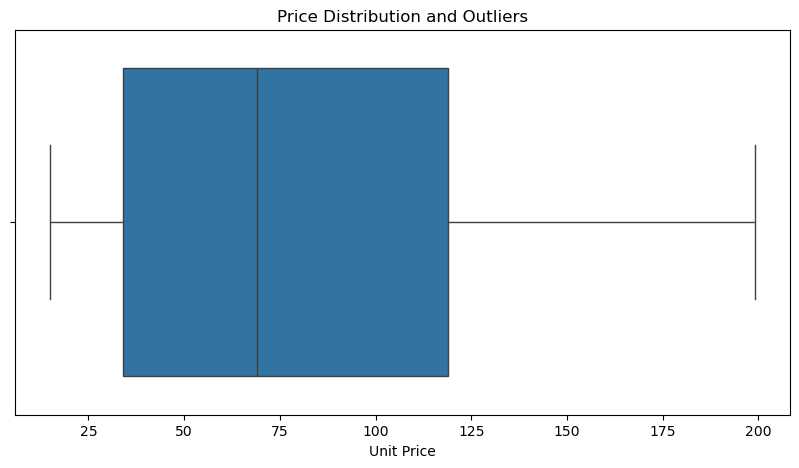

In [73]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=orders["unit_price"])
plt.title("Price Distribution and Outliers")
plt.xlabel("Unit Price")
plt.show()

Station C

1. Measures of center & spread

Order Values

In [76]:
orders["order_value"] = orders["quantity"] * orders["unit_price"]
print("Order Value Statistics:")
print(orders["order_value"].describe())

Order Value Statistics:
count    3363.000000
mean       88.230746
std        67.841938
min        15.000000
25%        39.000000
50%        72.000000
75%       119.000000
max       597.000000
Name: order_value, dtype: float64


Order values have a mean of 88.23 and a median of 72. The standard deviation is 67.84, showing considerable variation in order values.

Customer Order Count

In [77]:
customer_order_count = orders.groupby("customer_id").size()
print("Customer Order Count Statistics:")
print(customer_order_count.describe())

Customer Order Count Statistics:
count    850.000000
mean       3.956471
std        2.158990
min        1.000000
25%        2.000000
50%        4.000000
75%        6.000000
max       10.000000
dtype: float64


Customers placed an average of 3.96 orders, with a median of 4 orders. The standard deviation of 2.16 shows some variation in order frequency, with customers placing between 1 and 10 orders.

Association View

In [78]:
city_churn = customers.groupby("city")["churned"].mean()
print(city_churn)

city
Atlanta    0.121951
Austin     0.106383
Boston     0.100000
Chicago    0.160377
Dallas     0.141667
Denver     0.084746
Houston    0.303191
Miami      0.111111
Phoenix    0.107143
Seattle    0.166667
Name: churned, dtype: float64


Association: Churn rates differ across cities, with Houston having the highest observed rate and Denver the lowest. This is an association between city and churn; it does not by itself show that city causes churn.

Hypothesis Test - 1

churn rate in one city versus everyone else (here we are using houston because it has highest churn rate)

In [79]:
houston = customers[customers["city"] == "Houston"]
other_cities = customers[customers["city"] != "Houston"]
print("Houston customers:", len(houston))
print("Other city customers:", len(other_cities))

Houston customers: 188
Other city customers: 662


In [83]:
from statsmodels.stats.proportion import proportions_ztest
houston_churned = houston["churned"].sum()
other_churned = other_cities["churned"].sum()
count = [houston_churned, other_churned]
nobs = [len(houston), len(other_cities)]
z_stat, p_value = proportions_ztest(count, nobs)
print("Houston churned:", houston_churned)
print("Other cities churned:", other_churned)
print("Z-statistic:", z_stat)
print("P-value:", p_value)

Houston churned: 57
Other cities churned: 84
Z-statistic: 5.735153950683825
P-value: 9.74238124657715e-09


Hypothesis Test 1: Houston Churn vs Other Cities
1. H0: The churn rate in Houston is equal to the churn rate in other cities.
2. Test: Two-proportion z-test.
3. P-value: 9.74238124657715e-09
4. Interpretation: The p-value is below 0.05, so there is strong statistical evidence that the churn rate in Houston is different from the churn rate in other cities.
5. Manager takeaway: Houston shows a statistically significant difference in churn compared with the other cities, so it is worth investigating further.

Hypothesis Test 2

Return rate for one category versus the other categories.

In [84]:
kitchen = orders_products[orders_products["category"] == "Kitchen"]
other_categories = orders_products[orders_products["category"] != "Kitchen"]
print("Kitchen orders:", len(kitchen))
print("Other category orders:", len(other_categories))

Kitchen orders: 713
Other category orders: 2650


In [85]:
from statsmodels.stats.proportion import proportions_ztest
kitchen_returned = kitchen["returned"].sum()
other_returned = other_categories["returned"].sum()
count = [kitchen_returned, other_returned]
nobs = [len(kitchen), len(other_categories)]
z_stat, p_value = proportions_ztest(count, nobs)
print("Kitchen returned:", kitchen_returned)
print("Other categories returned:", other_returned)
print("Z-statistic:", z_stat)
print("P-value:", p_value)

Kitchen returned: 170
Other categories returned: 172
Z-statistic: 13.608211457580818
P-value: 3.5789540792438126e-42


Hypothesis Test 2: Kitchen Return Rate vs Other Categories
1. H0: The return rate for Kitchen products is equal to the return rate of other categories.
2. Test: Two-proportion z-test.
3. P-value: 3.58e-42.
4. Interpretation: The p-value is below 0.05, so there is strong statistical evidence that the Kitchen return rate differs from the return rate of other categories.
5. Manager takeaway: Kitchen products show a statistically significant difference in returns compared with other categories, so the category should be investigated further.